# FQL Succession P2 — **Verdict** (main aggregator)

**Pure-analysis notebook.** Reads the collected test-eval JSONs under `results/fql_succession/p2/<cell>/test/` and re-derives every table + figure in [`docs/fql_succession_p2_results.md`](../docs/fql_succession_p2_results.md). **No training, no GPU/Colab needed** — just the synced `results/` tree.

## Headline (mechanism finding + honest negative — NOT "FQL wins")

> A single fixed **ReBRAC β1 = 1.0** is ≥ FQL on **every** 2×2 cell and strictly more robust across the noise axis (**worst-case 0.910 vs FQL 0.858**). FQL's apparent advantage was an artifact of ReBRAC's *mis-tuned default* β1 = 4.0. Given its own BC-anchor sweep (C-1), FQL still cannot clear the bar.

The surviving contribution is the **mechanism**: *offline-RL robustness to action noise is governed by the **target quality** of the BC anchor, and the optimal anchor strength flips with that quality* — ReBRAC anchors to raw actions (must weaken β1 on noise), FQL to a flow-denoised target (already clean, but no clean-data edge).

## What this notebook outputs

1. §2 — the **2×2 modality × noise matrix** (noise, not modality, is the discriminator).
2. §3 — the **mechanism trilogy** (Q1 → Q1b → Q1c) + the **noise-axis grid**.
3. §4 — the **C-1 fairness rematch** (FQL's own `distill_alpha_bc` sweep → RESCUE-FAIL).
4. §5 — **statistical power** (fixed manifest ⇒ paired; σ_train ≈ 3.8 pp; t-tests).
5. §6 — the **auto-computed final verdict**.
6. §7 — the **cross-benchmark generalization probe** (`single_u15_cross` → FLOOR).

Authoritative source for any discrepancy: [`docs/fql_succession_p2_mechanism_diagnostic.md`](../docs/fql_succession_p2_mechanism_diagnostic.md) §9.

## 1. Locate repo root + load every test-eval `eval_success_rate`

在 repo root (local 或 Colab) 下定位 `results/fql_succession/p2`,把所有 cell × (algo, seed) 的 `eval_success_rate` 读进一个 dict。所有数字都从文件来,不硬编码。

In [1]:
import os, json
from pathlib import Path
from statistics import mean

# --- find repo root: cwd, then walk up, then known Colab mounts ---
def _is_root(p: Path) -> bool:
    return (p / 'auv_nav').is_dir() and (p / 'results' / 'fql_succession' / 'p2').is_dir()

root = None
for cand in [Path.cwd(), *Path.cwd().parents]:
    if _is_root(cand):
        root = cand; break
if root is None:
    for c in [Path('/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2_5'),
              Path('/content/drive/MyDrive/Colab Notebooks/new_offRL/rl_v2')]:
        if _is_root(c):
            root = c; break
if root is None:
    raise RuntimeError('repo root with results/fql_succession/p2 not found')
os.chdir(root)
print('repo root =', root)

P2 = Path('results/fql_succession/p2')

def sr(cell: str, fname: str):
    p = P2 / cell / 'test' / fname
    if not p.exists():
        return None
    return float(json.loads(p.read_text())['eval_success_rate'])

def cell_seeds(cell: str, algo: str, seeds):
    return [sr(cell, f'{algo}_seed{s}.json') for s in seeds]

def mu(vals):
    vals = [v for v in vals if v is not None]
    return mean(vals) if vals else None

print('loader ready.')

repo root = /Users/xiangjin/Library/CloudStorage/OneDrive-Personal/我的/Code/new_off_rl/rl_v2
loader ready.


## 2. The 2×2 matrix — noise, not modality, is the discriminator

Primary metric `eval_success_rate` (100 ep, fixed manifest ⇒ comparisons paired). δ = FQL − ReBRAC; verdict per spec v1.3 §5.5 (|δ|≤0.03 NULL, ≥0.05 & consistent POS/NEG, else GRAY).

E-uni FQL is at **n=4** (seeds 42,0 + C-1 top-up 1,2); all other cells n=2 {42,0}.

In [2]:
MATRIX = {
    'E-uni':       dict(label='clean / uni',   sigma='0.0', fql_seeds=[42, 0, 1, 2]),
    'M-uni-noise': dict(label='noisy / uni',   sigma='0.5', fql_seeds=[42, 0]),
    'E-multi':     dict(label='clean / multi', sigma='0.0', fql_seeds=[42, 0]),
    'M-multi-mix': dict(label='noisy / multi', sigma='0.1', fql_seeds=[42, 0]),
}
CELL_DIR = {'E-uni': 'e_uni', 'M-uni-noise': 'm_uni_noise',
            'E-multi': 'e_multi', 'M-multi-mix': 'm_multi_mix'}

def verdict(delta, consistent):
    ad = abs(delta)
    if ad <= 0.03: return 'NULL'
    if ad >= 0.05 and consistent: return 'POSITIVE' if delta > 0 else 'NEGATIVE'
    if 0.03 < ad < 0.05: return 'GRAY'
    return 'INCONSISTENT'

rows = []
print(f"{'cell':<13}{'role':<14}{'σ':>4} | {'ReBRAC μ':>9}{'FQL μ':>8}{'δ':>8}  verdict")
print('-' * 72)
for cell, cfg in MATRIX.items():
    d = CELL_DIR[cell]
    r = cell_seeds(d, 'rebrac', [42, 0])
    f = cell_seeds(d, 'fql', cfg['fql_seeds'])
    rmu, fmu = mu(r), mu(f)
    delta = fmu - rmu
    paired = [f[i] - r[i] for i in range(2)]   # seeds 42,0 paired
    consistent = (paired[0] > 0) == (paired[1] > 0)
    v = verdict(delta, consistent)
    rows.append((cell, cfg, rmu, fmu, delta, v))
    print(f"{cell:<13}{cfg['label']:<14}{cfg['sigma']:>4} | {rmu:>9.3f}{fmu:>8.3f}{delta:>+8.3f}  {v}")
print('-' * 72)
print('Only M-uni-noise (the high-noise cell) is POSITIVE. E-multi (clean multi) is NULL')
print('=> modality alone gives FQL nothing; the discriminator is action-noise magnitude.')

cell         role             σ |  ReBRAC μ   FQL μ       δ  verdict
------------------------------------------------------------------------
E-uni        clean / uni    0.0 |     0.885   0.858  -0.027  NULL
M-uni-noise  noisy / uni    0.5 |     0.705   0.910  +0.205  POSITIVE
E-multi      clean / multi  0.0 |     0.810   0.790  -0.020  NULL
M-multi-mix  noisy / multi  0.1 |     0.990   0.955  -0.035  GRAY
------------------------------------------------------------------------
Only M-uni-noise (the high-noise cell) is POSITIVE. E-multi (clean multi) is NULL
=> modality alone gives FQL nothing; the discriminator is action-noise magnitude.


wrote docs/assets/fql_succession_p2/verdict_matrix.png


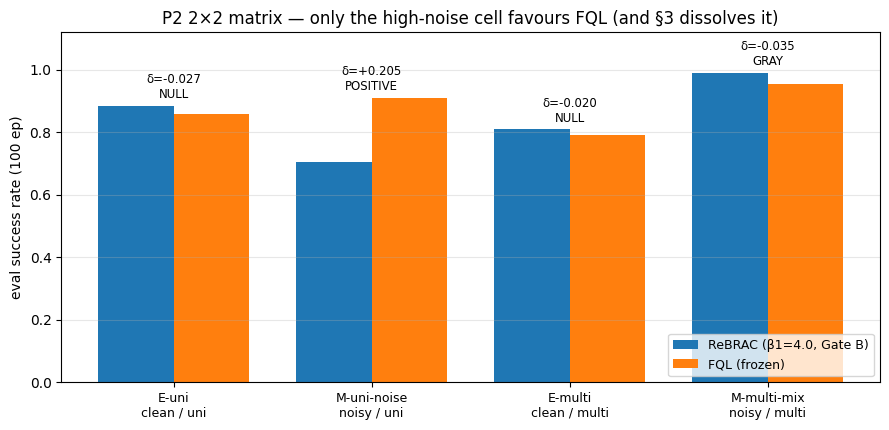

In [3]:
import matplotlib.pyplot as plt
import numpy as np

ASSETS = Path('docs/assets/fql_succession_p2'); ASSETS.mkdir(parents=True, exist_ok=True)

cells = [r[0] for r in rows]
rmus  = [r[2] for r in rows]
fmus  = [r[3] for r in rows]
x = np.arange(len(cells)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.4))
b1 = ax.bar(x - w/2, rmus, w, label='ReBRAC (β1=4.0, Gate B)', color='tab:blue')
b2 = ax.bar(x + w/2, fmus, w, label='FQL (frozen)', color='tab:orange')
for r in rows:
    i = cells.index(r[0])
    ax.annotate(f"δ={r[4]:+.3f}\n{r[5]}", (i, max(r[2], r[3]) + 0.015),
                ha='center', va='bottom', fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels([f"{c}\n{MATRIX[c]['label']}" for c in cells], fontsize=9)
ax.set_ylabel('eval success rate (100 ep)'); ax.set_ylim(0, 1.12)
ax.set_title('P2 2×2 matrix — only the high-noise cell favours FQL (and §3 dissolves it)')
ax.legend(loc='lower right', fontsize=9); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig(ASSETS / 'verdict_matrix.png', dpi=140, bbox_inches='tight')
print('wrote', ASSETS / 'verdict_matrix.png'); plt.show()

## 3. Mechanism trilogy + the noise-axis grid

A controlled chain on the noisy cell (and its clean control) isolates *which* ReBRAC BC surface causes the deficit and whether it's intrinsic:

| step | manipulation | conclusion |
|---|---|---|
| **Q1** | critic β2 2.0→0 (noisy) | critic-side penalty NOT the binding constraint (+0.01) |
| **Q1b** | actor β1 4.0→1.0 (noisy) | actor anchor strength IS the knob (+23.5 pp, overtakes FQL) |
| **Q1c** | actor β1 4.0→1.0 (clean) | β1=1.0 also better on clean → no trade-off |

Q1b + Q1c ⇒ the **noise-axis grid**, the decisive table: a single fixed ReBRAC β1=1.0 dominates FQL on both axes and on worst-case-over-noise.

In [4]:
# Mechanism-trilogy cells (all read from files).
q1   = cell_seeds('m_uni_noise_q1_critic_pen0',  'rebrac', [42, 0])  # critic β2=0, noisy
q1b  = cell_seeds('m_uni_noise_q1b_actor_pen1',  'rebrac', [42, 0])  # actor β1=1.0, noisy
q1c  = cell_seeds('e_uni_q1c_actor_pen1_clean',  'rebrac', [42, 0])  # actor β1=1.0, clean

rebrac_b4_clean = cell_seeds('e_uni', 'rebrac', [42, 0])             # β1=4.0 clean
rebrac_b4_noisy = cell_seeds('m_uni_noise', 'rebrac', [42, 0])       # β1=4.0 noisy
fql_clean = cell_seeds('e_uni', 'fql', [42, 0, 1, 2])               # FQL clean n=4
fql_noisy = cell_seeds('m_uni_noise', 'fql', [42, 0])               # FQL noisy

print('Q1  critic β2=0  (noisy): ', q1,  '-> μ', round(mu(q1), 3),  ' vs β1=4.0 noisy μ', round(mu(rebrac_b4_noisy), 3))
print('Q1b actor β1=1.0 (noisy): ', q1b, '-> μ', round(mu(q1b), 3), ' (overtakes FQL noisy μ', round(mu(fql_noisy), 3), ')')
print('Q1c actor β1=1.0 (clean): ', q1c, '-> μ', round(mu(q1c), 3), ' vs β1=4.0 clean μ', round(mu(rebrac_b4_clean), 3))

GRID = {
    'ReBRAC β1=4.0 (Gate B)': (mu(rebrac_b4_clean), mu(rebrac_b4_noisy)),
    'ReBRAC β1=1.0':          (mu(q1c),             mu(q1b)),
    'FQL (frozen)':           (mu(fql_clean),       mu(fql_noisy)),
}
print()
print(f"{'config':<26}{'clean':>8}{'noisy':>8}{'worst-case':>12}")
print('-' * 54)
for name, (c, n) in GRID.items():
    print(f'{name:<26}{c:>8.3f}{n:>8.3f}{min(c, n):>12.3f}')
print('-' * 54)
wc = {k: min(v) for k, v in GRID.items()}
best = max(wc, key=wc.get)
print(f'worst-case ranking: ' + ' > '.join(f'{k} ({wc[k]:.3f})' for k in sorted(wc, key=wc.get, reverse=True)))
print(f'=> {best} is the most noise-robust config; FQL is dominated on BOTH axes.')

Q1  critic β2=0  (noisy):  [0.75, 0.68] -> μ 0.715  vs β1=4.0 noisy μ 0.705
Q1b actor β1=1.0 (noisy):  [0.98, 0.9] -> μ 0.94  (overtakes FQL noisy μ 0.91 )
Q1c actor β1=1.0 (clean):  [0.88, 0.94] -> μ 0.91  vs β1=4.0 clean μ 0.885

config                       clean   noisy  worst-case
------------------------------------------------------
ReBRAC β1=4.0 (Gate B)       0.885   0.705       0.705
ReBRAC β1=1.0                0.910   0.940       0.910
FQL (frozen)                 0.858   0.910       0.858
------------------------------------------------------
worst-case ranking: ReBRAC β1=1.0 (0.910) > FQL (frozen) (0.858) > ReBRAC β1=4.0 (Gate B) (0.705)
=> ReBRAC β1=1.0 is the most noise-robust config; FQL is dominated on BOTH axes.


wrote docs/assets/fql_succession_p2/verdict_noise_axis.png


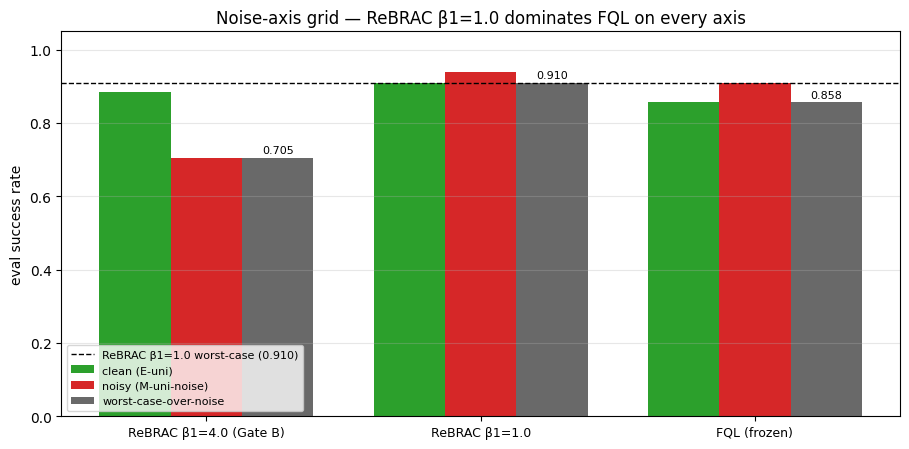

In [5]:
labels = list(GRID.keys())
clean_v = [GRID[k][0] for k in labels]
noisy_v = [GRID[k][1] for k in labels]
wc_v    = [min(GRID[k]) for k in labels]
x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(x - w, clean_v, w, label='clean (E-uni)', color='tab:green')
ax.bar(x,     noisy_v, w, label='noisy (M-uni-noise)', color='tab:red')
ax.bar(x + w, wc_v,    w, label='worst-case-over-noise', color='dimgray')
ax.axhline(min(GRID['ReBRAC β1=1.0']), color='black', ls='--', lw=1,
           label=f"ReBRAC β1=1.0 worst-case ({min(GRID['ReBRAC β1=1.0']):.3f})")
for i, k in enumerate(labels):
    ax.annotate(f'{min(GRID[k]):.3f}', (i + w, min(GRID[k]) + 0.012), ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('eval success rate'); ax.set_ylim(0, 1.05)
ax.set_title('Noise-axis grid — ReBRAC β1=1.0 dominates FQL on every axis')
ax.legend(loc='lower left', fontsize=8); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); fig.savefig(ASSETS / 'verdict_noise_axis.png', dpi=140, bbox_inches='tight')
print('wrote', ASSETS / 'verdict_noise_axis.png'); plt.show()

## 4. C-1 fairness rematch — FQL gets its own knob, still loses

Q1c tuned ReBRAC's β1 while FQL's `distill_alpha_bc` stayed frozen at 1.0. C-1 closes that asymmetry: sweep FQL's own BC-anchor knob log-spaced on the **clean** axis (FQL's worst-case axis) and top up α=1.0 to **n=4**. The bar to clear: **0.910** (ReBRAC β1=1.0 worst-case).

In [6]:
SWEEP = Path('results/fql_succession/p2/e_uni_c1_fql_alpha_sweep/test')

def fql_alpha_clean(alpha):
    if alpha == 1.0:
        return cell_seeds('e_uni', 'fql', [42, 0, 1, 2])   # n=4 (incl. top-up)
    tag = str(alpha).replace('.', 'p')
    return [float(json.loads((SWEEP / f'fql_a{tag}_seed{s}.json').read_text())['eval_success_rate'])
            if (SWEEP / f'fql_a{tag}_seed{s}.json').exists() else None for s in [42, 0]]

ALPHAS = [0.3, 1.0, 3.0, 10.0]
BAR = min(GRID['ReBRAC β1=1.0'])   # 0.910

c1 = {}
print(f"{'distill_alpha_bc':>16} | {'per-seed':<26} | {'mean':>6} | n")
print('-' * 60)
for a in ALPHAS:
    vals = [v for v in fql_alpha_clean(a) if v is not None]
    c1[a] = mu(vals)
    tag = '  <- frozen (n=4)' if a == 1.0 else ''
    cells_s = ', '.join(f'{v:.2f}' for v in vals)
    print(f'{a:>16} | {cells_s:<26} | {c1[a]:>6.3f} | {len(vals)}{tag}')
print('-' * 60)
print(f'{"ReBRAC β1=1.0 (bar)":>16} | {"0.88, 0.94":<26} | {BAR:>6.3f} | 2')

best_a = max(c1, key=c1.get); best_clean = c1[best_a]
print()
print(f'best FQL clean = {best_clean:.3f} at α={best_a}   gap to bar = {best_clean - BAR:+.3f}')
if best_clean >= 0.90:   v = 'RESCUE-PROMISING'
elif best_clean >= 0.86: v = 'RESCUE-WEAK'
else:                    v = 'RESCUE-FAIL'
print(f'C-1 VERDICT: {v}  (no α clears the {BAR:.3f} bar)' if best_clean < BAR else f'C-1 VERDICT: {v}')

distill_alpha_bc | per-seed                   |   mean | n
------------------------------------------------------------
             0.3 | 0.75, 0.73                 |  0.740 | 2
             1.0 | 0.80, 0.91, 0.91, 0.81     |  0.858 | 4  <- frozen (n=4)
             3.0 | 0.86, 0.72                 |  0.790 | 2
            10.0 | 0.86, 0.85                 |  0.855 | 2
------------------------------------------------------------
ReBRAC β1=1.0 (bar) | 0.88, 0.94                 |  0.910 | 2

best FQL clean = 0.858 at α=1.0   gap to bar = -0.052
C-1 VERDICT: RESCUE-FAIL  (no α clears the 0.910 bar)


wrote docs/assets/fql_succession_p2/verdict_c1_rescue.png


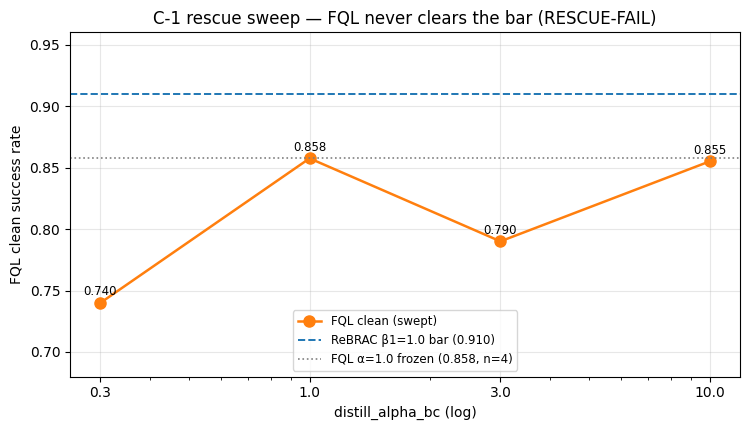

In [7]:
ax_a = [a for a in ALPHAS if c1[a] is not None]
ax_v = [c1[a] for a in ax_a]
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(ax_a, ax_v, 'o-', color='tab:orange', lw=1.8, ms=8, label='FQL clean (swept)')
for a, v in zip(ax_a, ax_v):
    ax.annotate(f'{v:.3f}', (a, v + 0.006), ha='center', fontsize=8.5)
ax.axhline(BAR, color='tab:blue', ls='--', lw=1.4, label=f'ReBRAC β1=1.0 bar ({BAR:.3f})')
ax.axhline(c1[1.0], color='gray', ls=':', lw=1.2, label=f'FQL α=1.0 frozen ({c1[1.0]:.3f}, n=4)')
ax.set_xscale('log'); ax.set_xticks(ax_a); ax.set_xticklabels([str(a) for a in ax_a])
ax.set_xlabel('distill_alpha_bc (log)'); ax.set_ylabel('FQL clean success rate')
ax.set_ylim(0.68, 0.96)
ax.set_title('C-1 rescue sweep — FQL never clears the bar (RESCUE-FAIL)')
ax.legend(loc='lower center', fontsize=8.5); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(ASSETS / 'verdict_c1_rescue.png', dpi=140, bbox_inches='tight')
print('wrote', ASSETS / 'verdict_c1_rescue.png'); plt.show()

## 5. Statistical power — is n=2 enough?

Fixed manifest ⇒ eval noise common-mode ⇒ comparisons paired, seed spread = pure training variance (σ_train ≈ 3.8 pp). Two-sample t (Welch, n per group, t_crit≈4.30 at df≈2). The two **large** effects are significant at n=2; the FQL head-to-heads are NULL with point estimates tilting *against* FQL → more seeds tighten NULLs, they don't resurrect FQL.

In [8]:
from math import sqrt

def var1(vals):
    vals = [v for v in vals if v is not None]; n = len(vals)
    if n < 2: return 0.0
    m = mean(vals); return sum((v - m) ** 2 for v in vals) / (n - 1)

def ttest(a, b):
    a = [v for v in a if v is not None]; b = [v for v in b if v is not None]
    na, nb = len(a), len(b)
    delta = mean(a) - mean(b)
    se = sqrt(var1(a) / na + var1(b) / nb)
    t = delta / se if se > 0 else float('inf')
    return delta, se, t

contrasts = [
    ('Q1b β1=1.0 vs β1=4.0 (noisy)  [keystone]', q1b, rebrac_b4_noisy),
    ('FQL vs β1=4.0 (noisy)  [original win]',    fql_noisy, rebrac_b4_noisy),
    ('β1=1.0 vs FQL (clean)  [head-to-head]',    q1c, fql_clean),
    ('β1=1.0 vs FQL (noisy)  [head-to-head]',    q1b, fql_noisy),
    ('β1=1.0 vs β1=4.0 (clean)',                 q1c, rebrac_b4_clean),
    ('FQL α=1.0 (n=4) vs bar (clean) [C-1]',      fql_clean, q1c),
]
TCRIT = 4.30
print(f"{'contrast':<44}{'δ':>8}{'SE':>7}{'t':>7}  verdict")
print('-' * 76)
for name, a, b in contrasts:
    d, se, t = ttest(a, b)
    v = 'SIG' if abs(t) >= TCRIT else 'NULL'
    print(f'{name:<44}{d:>+8.3f}{se:>7.3f}{t:>7.2f}  {v}')
print('-' * 76)
print('Large effects (Q1b, original win) SIG at n=2; every FQL head-to-head NULL & tilts against FQL.')

contrast                                           δ     SE      t  verdict
----------------------------------------------------------------------------
Q1b β1=1.0 vs β1=4.0 (noisy)  [keystone]      +0.235  0.047   4.98  SIG
FQL vs β1=4.0 (noisy)  [original win]         +0.205  0.025   8.20  SIG
β1=1.0 vs FQL (clean)  [head-to-head]         +0.052  0.043   1.23  NULL
β1=1.0 vs FQL (noisy)  [head-to-head]         +0.030  0.040   0.75  NULL
β1=1.0 vs β1=4.0 (clean)                      +0.025  0.030   0.82  NULL
FQL α=1.0 (n=4) vs bar (clean) [C-1]          -0.052  0.043  -1.23  NULL
----------------------------------------------------------------------------
Large effects (Q1b, original win) SIG at n=2; every FQL head-to-head NULL & tilts against FQL.


## 6. Final verdict (auto)

Assembles the decision from the numbers above. Expected: **B + A LOCKED** — mechanism finding + honest negative; "FQL wins" falsified on every front.

In [9]:
fql_wc = min(GRID['FQL (frozen)'])
rebrac_wc = min(GRID['ReBRAC β1=1.0'])
dominates_clean = GRID['ReBRAC β1=1.0'][0] >= GRID['FQL (frozen)'][0]
dominates_noisy = GRID['ReBRAC β1=1.0'][1] >= GRID['FQL (frozen)'][1]
c1_failed = best_clean < rebrac_wc

print('=' * 68)
print('  FQL SUCCESSION P2 — FINAL VERDICT')
print('=' * 68)
print(f'  ReBRAC β1=1.0 ≥ FQL on clean : {dominates_clean}  ({GRID["ReBRAC β1=1.0"][0]:.3f} vs {GRID["FQL (frozen)"][0]:.3f})')
print(f'  ReBRAC β1=1.0 ≥ FQL on noisy : {dominates_noisy}  ({GRID["ReBRAC β1=1.0"][1]:.3f} vs {GRID["FQL (frozen)"][1]:.3f})')
print(f'  worst-case-over-noise        : ReBRAC {rebrac_wc:.3f}  >  FQL {fql_wc:.3f}')
print(f'  C-1 fairness rematch failed  : {c1_failed}  (best FQL clean {best_clean:.3f} < bar {rebrac_wc:.3f})')
print('-' * 68)
if dominates_clean and dominates_noisy and c1_failed:
    print('  VERDICT: "FQL > ReBRAC" FALSIFIED on every front.')
    print('  DECISION: B + A LOCKED — mechanism finding + honest negative.')
    print('  Mechanism: BC-anchor TARGET QUALITY drives noise-robustness;')
    print('             optimal anchor strength flips with target noise.')
    print('  Next: N4 — rewrite spec v1.3 -> v1.4 to this framing.')
else:
    print('  VERDICT: unexpected — re-check inputs against §9 of the diagnostic doc.')
print('=' * 68)

  FQL SUCCESSION P2 — FINAL VERDICT
  ReBRAC β1=1.0 ≥ FQL on clean : True  (0.910 vs 0.858)
  ReBRAC β1=1.0 ≥ FQL on noisy : True  (0.940 vs 0.910)
  worst-case-over-noise        : ReBRAC 0.910  >  FQL 0.858
  C-1 fairness rematch failed  : True  (best FQL clean 0.858 < bar 0.910)
--------------------------------------------------------------------
  VERDICT: "FQL > ReBRAC" FALSIFIED on every front.
  DECISION: B + A LOCKED — mechanism finding + honest negative.
  Mechanism: BC-anchor TARGET QUALITY drives noise-robustness;
             optimal anchor strength flips with target noise.
  Next: N4 — rewrite spec v1.3 -> v1.4 to this framing.


---

**Provenance.** Every number above is read live from `results/fql_succession/p2/<cell>/test/<algo>_seed<seed>.json`. The narrative report is [`docs/fql_succession_p2_results.md`](../docs/fql_succession_p2_results.md); the full lab record is [`docs/fql_succession_p2_mechanism_diagnostic.md`](../docs/fql_succession_p2_mechanism_diagnostic.md) §9 (authoritative). Figures saved under `docs/assets/fql_succession_p2/`.

## 7. Cross-benchmark generalization probe — `single_u15_cross` (FLOOR)

A minimal probe on the harder `single_u15_cross` (U=1.5 / Re250) to test generalization beyond the main `single_u10_cross`, gated by one learnability run before the full 12-run matrix (spec [`docs/fql_succession_p2_xbench_spec.md`](../docs/fql_succession_p2_xbench_spec.md)).

**It FLOORED** — the gate run scored far below the (0.50, 0.97) window, so the matrix was never run. The FQL-vs-ReBRAC comparison is *undefined* in this regime: a deployable-`s0` sensor-sufficiency boundary, not an algorithmic counter-result. See [`docs/fql_succession_p2_results.md`](../docs/fql_succession_p2_results.md) §6.5.

In [10]:
# Collector SRs come from collection metadata under offline_data/ (gitignored, not in
# the results tree); recorded from the completed run for context.
XB_CLEAN_COLLECTOR = 0.719   # privileged σ=0   (vs u10 0.985)
XB_NOISY_COLLECTOR = 0.098   # privileged σ=0.5 (vs u10 0.632)

xb_gate = Path('results/fql_succession/p2_xbench/e_uni_clean/test/rebrac_b1p1_seed42.json')
xb_sr = float(json.loads(xb_gate.read_text())['eval_success_rate']) if xb_gate.exists() else None

print('single_u15_cross (U=1.5/Re250) generalization probe')
print('-' * 58)
print(f'  clean privileged collector SR : {XB_CLEAN_COLLECTOR:.3f}   (u10: 0.985)')
print(f'  noisy privileged collector SR : {XB_NOISY_COLLECTOR:.3f}   (u10: 0.632)')
if xb_sr is None:
    print('  gate run (ReBRAC β1=1.0/clean) : [results not synced]')
else:
    print(f'  gate run ReBRAC β1=1.0 / clean : {xb_sr:.3f}   test SR  (u10: ~0.910)')
    if xb_sr <= 0.50:
        print('  VERDICT: FLOOR (SR ≤ 0.50, outside (0.50, 0.97)) — s0 observability floor at U=1.5.')
        print('           comparison undefined here; scope caveat, not a counter-result.')
    elif xb_sr >= 0.97:
        print('  VERDICT: CEILING — no discriminating headroom.')
    else:
        print('  VERDICT: PASS — (unexpected; the full matrix should have run).')

single_u15_cross (U=1.5/Re250) generalization probe
----------------------------------------------------------
  clean privileged collector SR : 0.719   (u10: 0.985)
  noisy privileged collector SR : 0.098   (u10: 0.632)
  gate run ReBRAC β1=1.0 / clean : 0.140   test SR  (u10: ~0.910)
  VERDICT: FLOOR (SR ≤ 0.50, outside (0.50, 0.97)) — s0 observability floor at U=1.5.
           comparison undefined here; scope caveat, not a counter-result.
